In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = r'Z:\Internship\Tasks\Edge Detection\image\test7.jpeg'
image = cv2.imread(image_path)

gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray_image, (3,3), 0)

In [2]:
_, thresh_init = cv2.threshold(blurred, 200, 255, cv2.THRESH_BINARY) 

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
closed = cv2.morphologyEx(thresh_init, cv2.MORPH_CLOSE, kernel)
contours, hierarchy = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

min_area = 500 
valid_contours = [c for c in contours if cv2.contourArea(c) > min_area]

t, b, l, r = [], [], [], []
con = []  

In [3]:
con = []  
for contour in valid_contours: 
    x, y, w, h = cv2.boundingRect(contour)
    pad = 0
    
    x_start, x_end = max(0, x - pad), min(image.shape[1], x + w + pad)
    y_start, y_end = max(0, y - pad), min(image.shape[0], y + h + pad)
    
    cropped_piece = image[y_start:y_end, x_start:x_end]
    
    mask = np.zeros_like(closed)
    cv2.drawContours(mask, [contour], -1, 255, -1) 

    cropped_mask = mask[y_start:y_end, x_start:x_end]
    isolated_piece = cv2.bitwise_and(cropped_piece, cropped_piece, mask=cropped_mask)
    
    con.append(isolated_piece)

In [4]:
t, b, l, r = [], [], [], []

for current_piece in con: 
    padded_image = cv2.copyMakeBorder(current_piece, 10, 10, 10, 10, borderType=cv2.BORDER_CONSTANT, value=[0,0,0])
    
    gray = cv2.cvtColor(padded_image, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)
    
    points = cv2.findNonZero(thresh)
    
    x_box, y_box, w_box, h_box = cv2.boundingRect(points)

    tol = 1.5 
    top_deviations, bottom_deviations = [], []

    for col in range(x_box, x_box + w_box):
        white_pixels = np.where(thresh[:, col] == 255)[0]
        if len(white_pixels) > 0:
            top_deviations.append(int(white_pixels[0] - y_box))
            bottom_deviations.append(int((y_box + h_box) - white_pixels[-1]))

    std_top = np.std(top_deviations) if top_deviations else 0
    std_bottom = np.std(bottom_deviations) if bottom_deviations else 0
    
    top_is_torn = std_top > tol
    bottom_is_torn = std_bottom > tol
    
    print(f"Top :    {'TORN' if top_is_torn else 'STRAIGHT'} (variance: {std_top:.2f}px)")
    print(f"Bottom : {'TORN' if bottom_is_torn else 'STRAIGHT'} (variance: {std_bottom:.2f}px)")

    left_avg, right_avg = [], []
    for row in range(y_box, y_box + h_box):
        white_pixels = np.where(thresh[row, :] == 255)[0]
        if len(white_pixels) > 0:
            left_avg.append(int(white_pixels[0] - x_box))
            right_avg.append(int((x_box + w_box) - white_pixels[-1]))

    std_left = np.std(left_avg) if left_avg else 0
    std_right = np.std(right_avg) if right_avg else 0
    
    left_is_torn = std_left > tol
    right_is_torn = std_right > tol
    
    print(f"Left :   {'TORN' if left_is_torn else 'STRAIGHT'} (avg: {std_left:.2f}px)")
    print(f"Right :  {'TORN' if right_is_torn else 'STRAIGHT'} (avg: {std_right:.2f}px)")

    a1 = cv2.Canny(thresh, 150, 150)
    y_arr, x_arr = np.where(a1 == 255)
    
    y_pixels, x_pixels = np.where(thresh == 255)
    min_y, max_y = np.min(y_pixels), np.max(y_pixels)
    min_x, max_x = np.min(x_pixels), np.max(x_pixels)
    
    g1 = 5  
    any_torn = False

    if top_is_torn:
        any_torn = True
        b11_top = []
        for col_x in range(min_x, max_x + 1):
            pixels_in_col = y_arr[x_arr == col_x]
            if len(pixels_in_col) > 0:
                b11_top.append((int(col_x), int(np.min(pixels_in_col))))
        
        top_ref_y = int(min_y - g1)
        distances_top = [abs(int(y11) - top_ref_y) for _, y11 in b11_top]
        t.append(distances_top)
        print(f"TOP Distances{distances_top}")
    else:
        t.append([])    

    if bottom_is_torn:
        any_torn = True
        b11_bottom = []
        for col_x in range(min_x, max_x + 1):
            pixels_in_col = y_arr[x_arr == col_x]
            if len(pixels_in_col) > 0:
                b11_bottom.append((int(col_x), int(np.max(pixels_in_col))))
        
        bottom_ref_y = int(max_y + g1)
        distances_bottom = [abs(int(y11) - bottom_ref_y) for _, y11 in b11_bottom]
        b.append(distances_bottom)
        print(f"BOTTOM Distances{distances_bottom}")
    else:
         b.append([])    

    if left_is_torn:
        any_torn = True
        b11_left = []
        for row_y in range(min_y, max_y + 1):
            pixels_in_row = x_arr[y_arr == row_y]
            if len(pixels_in_row) > 0:
                b11_left.append((int(row_y), int(np.min(pixels_in_row))))
        
        left_ref_x = int(min_x - g1)
        distances_left = [abs(int(x11) - left_ref_x) for _, x11 in b11_left]
        l.append(distances_left)
        print(f"LEFT Distances {distances_left}")
    else:
          l.append([])    

    if right_is_torn:
        any_torn = True
        b11_right = []
        for row_y in range(min_y, max_y + 1):
            pixels_in_row = x_arr[y_arr == row_y]
            if len(pixels_in_row) > 0:
                b11_right.append((int(row_y), int(np.max(pixels_in_row))))
        
        right_ref_x = int(max_x + g1)
        distances_right = [abs(int(x11) - right_ref_x) for _, x11 in b11_right]
        r.append(distances_right)
        print(f"RIGHT Distances{distances_right}")
    else:
         r.append([])
    
    plt.imshow(thresh, cmap='gray')
    plt.show()

In [5]:
th = 0.82
tr = 12

def check_match(side1, side2):
    if not isinstance(side1, list) or not isinstance(side2, list):
        return False, 0.0
    if len(side1) == 0 or len(side2) == 0:
        return False, 0.0

    edge1 = np.array(side1 if len(side1) > 2*tr else side1, dtype=float)
    edge2 = np.array(side2 if len(side2) > 2*tr else side2, dtype=float)

    x1 = np.arange(len(edge1))
    slope1, intercept1 = np.polyfit(x1, edge1, 1)
    detrended1 = edge1 - (slope1 * x1 + intercept1)
    roughness1 = np.std(detrended1)

    x2 = np.arange(len(edge2))
    slope2, intercept2 = np.polyfit(x2, edge2, 1)
    detrended2 = edge2 - (slope2 * x2 + intercept2)
    roughness2 = np.std(detrended2)

    if roughness1 < 1.2 or roughness2 < 1.2:
        return False, 0.0
      
    norm1 = (edge1 - np.min(edge1)) / (np.max(edge1) - np.min(edge1) + 1e-6)
    norm2 = (edge2 - np.min(edge2)) / (np.max(edge2) - np.min(edge2) + 1e-6)

    if len(norm1) < len(norm2):
        shorter, longer = norm1, norm2
    else:
        shorter, longer = norm2, norm1
        
    s_len, l_len = len(shorter), len(longer)
    best_score = 0.0

    for direction in ["Forward", "Reversed"]:
        test_shorter = shorter if direction == "Forward" else shorter[::-1]
        
        for offset in range(l_len - s_len + 1):
            segment = longer[offset:offset + s_len]
            
            dist_direct = np.mean(np.abs(test_shorter - segment))
            score_direct = 1.0 - dist_direct
            
            dist_comp = np.mean(np.abs(test_shorter - (1.0 - segment)))
            score_comp = 1.0 - dist_comp
            
            if score_direct > best_score:
                best_score = score_direct
                
            if score_comp > best_score:
                best_score = score_comp

    confidence = best_score * 100
    if best_score >= th:
        return True, confidence
    else:
        return False, confidence

In [6]:
num_pieces = len(con)

for i in range(num_pieces):
    for j in range(num_pieces):
        if i == j:
            continue
            
        matched, conf = check_match(t[i], b[j])
        status = "MATCHED" if matched else "NOT MATCHED"
        print(f"Piece {i} (TOP) Piece {j} (BOTTOM)  {status} (Confidence {conf:.2f}%)")

        matched, conf = check_match(b[i], t[j])
        status = "MATCHED" if matched else "NOT MATCHED"
        print(f"Piece {i} (BOTTOM) Piece {j} (TOP)  {status} (Confidence {conf:.2f}%)")

for i in range(num_pieces):
    for j in range(num_pieces):
        if i == j:
            continue

        matched, conf = check_match(l[i], r[j])
        status = "MATCHED" if matched else "NOT MATCHED"
        print(f"Piece {i} (LEFT)  Piece {j} (RIGHT)  {status} (Confidence {conf:.2f}%)")

        matched, conf = check_match(r[i], l[j])
        status = "MATCHED" if matched else "NOT MATCHED"
        print(f"Piece {i} (RIGHT)  Piece {j} (LEFT)  {status} (Confidence {conf:.2f}%)")

Detected 10 distinct paper fragments.


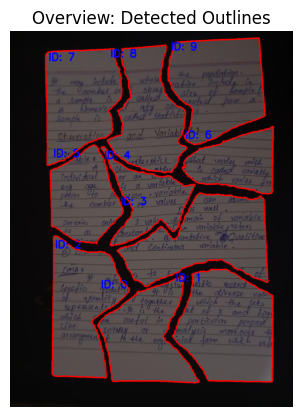

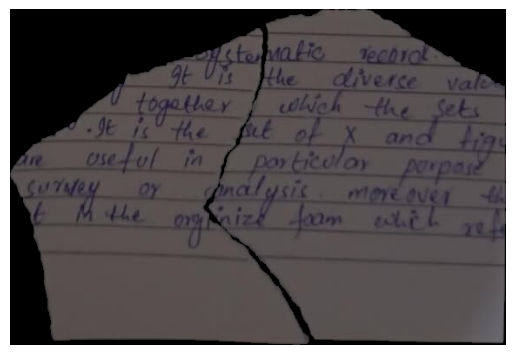

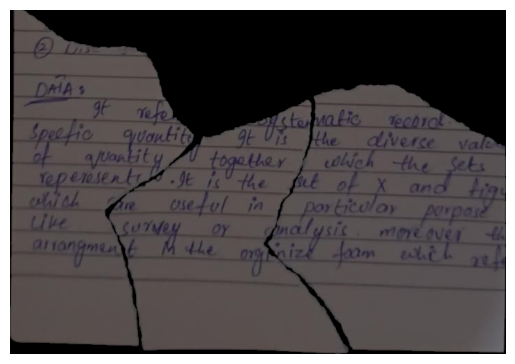

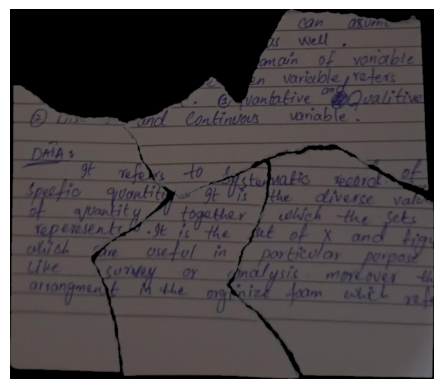

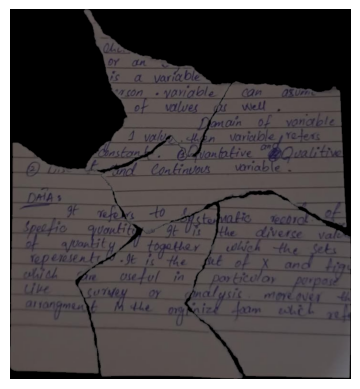

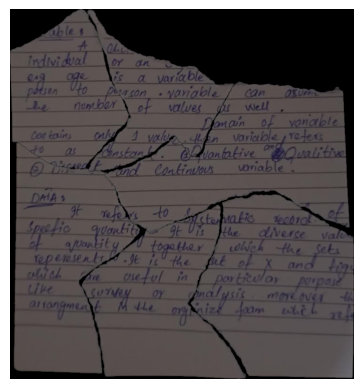

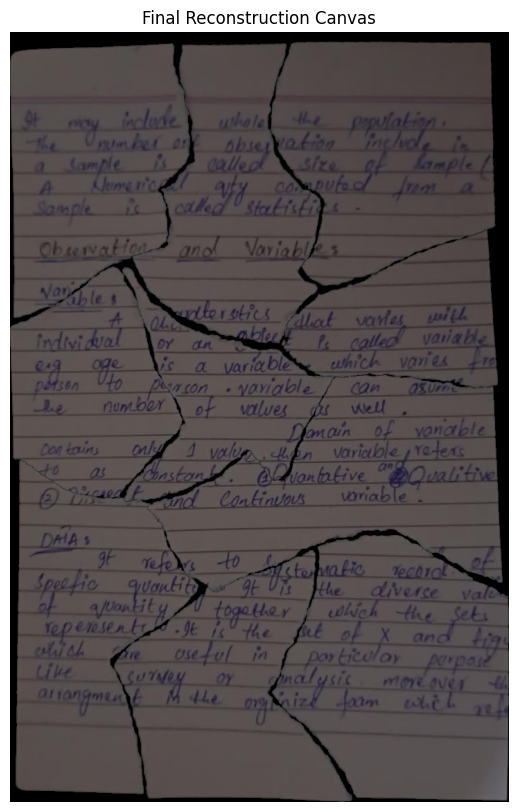

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

isolated_pieces_list = []


def display_detected_fragments(image_path):
    global isolated_pieces_list
    img = cv2.imread(image_path)
    if img is None:
        print("Error: Image could not be loaded. Check your file path.")
        return None, None

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, c = img.shape

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    _, thresh = cv2.threshold(
        gray, 250, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

    contours, _ = cv2.findContours(
        thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    min_area = (h * w) * 0.009
    fragments = [c for c in contours if cv2.contourArea(c) > min_area]

    print(f"Detected {len(fragments)} distinct paper fragments.")

    highlighted_img = img_rgb.copy()
    num_fragments = len(fragments)
    cols = 3
    rows = (num_fragments + 1 + (cols - 1)) // cols

    plt.figure(figsize=(15, rows * 4))

    for idx, contour in enumerate(fragments):
        cv2.drawContours(
            highlighted_img, [contour], -1, (255, 0, 0), 4
        )  
        x, y, pw, ph = cv2.boundingRect(contour)
        cv2.putText(
            highlighted_img,
            f"ID: {idx}",
            (x + 10, y + 40),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.2,
            (0, 0, 255),
            3,
        )

    plt.subplot(rows, cols, 1)
    plt.imshow(highlighted_img)
    plt.title("Overview: Detected Outlines")
    plt.axis("off")

    temporary_storage = []
    for idx, contour in enumerate(fragments):
        mask = np.zeros_like(gray)
        cv2.drawContours(mask, [contour], -1, 255, thickness=cv2.FILLED)

        piece = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)

        x, y, pw, ph = cv2.boundingRect(contour)
        cropped_piece = piece[y : y + ph, x : x + pw]

        cropped_bgr = cv2.cvtColor(cropped_piece, cv2.COLOR_RGB2BGR)

        temporary_storage.append(
            {"img": cropped_bgr, "orig_x": x, "orig_y": y}
        )

    plt.tight_layout()
    plt.show()

    return temporary_storage, w




def get_thresh(img):
    return cv2.threshold(
        cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), 15, 255, cv2.THRESH_BINARY
    )[1]


def merge_canvases(imgA, imgB, threshA, threshB, dx, dy):
    hA, wA = imgA.shape[:2]
    hB, wB = imgB.shape[:2]
    min_x, max_x = min(0, dx), max(wA, wB + dx)
    min_y, max_y = min(0, dy), max(hA, hB + dy)
    canvas = np.zeros((max_y - min_y, max_x - min_x, 3), dtype=np.uint8)
    canvas[-min_y : -min_y + hA, -min_x : -min_x + wA][threshA > 0] = imgA[
        threshA > 0
    ]
    canvas[dy - min_y : dy - min_y + hB, dx - min_x : dx - min_x + wB][
        threshB > 0
    ] = imgB[threshB > 0]
    return canvas


def stitch_by_edge(img2, img3, ref="bottom"):
    thresh2, thresh3 = get_thresh(img2), get_thresh(img3)
    p2, p3 = np.where(thresh2 == 255), np.where(thresh3 == 255)
    dy = (
        (int(p2[0].max()) - int(p3[0].max()))
        if ref == "bottom"
        else (int(p2[0].min()) - int(p3[0].min()))
    )

    y2, x2 = np.where(cv2.Canny(thresh2, 150, 150) == 255)
    b2 = {
        r: np.max(x2[y2 == r])
        for r in range(np.min(p2[0]), np.max(p2[0]) + 1)
        if len(x2[y2 == r]) > 0
    }
    y3, x3 = np.where(cv2.Canny(thresh3, 150, 150) == 255)
    b3 = {
        r: np.min(x3[y3 == r])
        for r in range(np.min(p3[0]), np.max(p3[0]) + 1)
        if len(x3[y3 == r]) > 0
    }

    dx = int(
        np.percentile(
            [b2[y + dy] - x for y, x in b3.items() if (y + dy) in b2], 90
        )
    )
    return merge_canvases(img2, img3, thresh2, thresh3, dx, dy)


def stitch_by_margin(img0, img1, side="left"):
    thresh0, thresh1 = get_thresh(img0), get_thresh(img1)
    y0, x0 = np.where(thresh0 == 255)
    y1, x1 = np.where(thresh1 == 255)

    dx = (np.min(x0) if side == "left" else np.max(x0)) - (
        np.min(x1) if side == "left" else np.max(x1)
    )
    bottom0 = {c: np.max(y0[x0 == c]) for c in np.unique(x0)}
    top1 = {c + dx: np.min(y1[x1 == c]) for c in np.unique(x1)}

    dy = int(
        np.percentile(
            [bottom0[c] - top1[c] + 1 for c in bottom0 if c in top1], 92
        )
    )
    return merge_canvases(img0, img1, thresh0, thresh1, dx, dy)


def ad_stitch(img_base, img_patch):
    m_b = (
        (cv2.cvtColor(img_base, cv2.COLOR_BGR2GRAY) > 15) * 255
    ).astype(np.uint8)
    m_p = (
        (cv2.cvtColor(img_patch, cv2.COLOR_BGR2GRAY) > 15) * 255
    ).astype(np.uint8)

    y_p, x_p = np.where(cv2.Canny(m_p, 50, 150) == 255)
    dist_out, dist_in = cv2.distanceTransform(
        ~m_b, cv2.DIST_L2, 5
    ), cv2.distanceTransform(m_b, cv2.DIST_L2, 5)

    h_b, w_b = img_base.shape[:2]
    h_p, w_p = img_patch.shape[:2]
    best_dx, best_dy, min_score = 0, 0, float("inf")

    for dy in range(-int(h_b * 0.8), int(h_b * 0.8)):
        for dx in range(-int(w_b * 0.8), int(w_b * 1.2)):
            sy, sx = y_p + dy, x_p + dx
            valid = (sy >= 0) & (sy < h_b) & (sx >= 0) & (sx < w_b)
            if np.sum(valid) < 15:
                continue

            vy, vx = sy[valid], sx[valid]
            ol = m_b[vy, vx] == 255
            n_vy, n_vx = vy[~ol], vx[~ol]

            touching = (
                np.sum(dist_out[n_vy, n_vx] <= 6.0) if len(n_vy) > 0 else 0
            )
            deep = np.sum(dist_in[vy[ol], vx[ol]] > 8.0) if np.sum(ol) > 0 else 0
            score = -touching + (4.0 * deep)

            if score < min_score:
                min_score, best_dx, best_dy = score, dx, dy

    oy, ox = max(0, -best_dy), max(0, -best_dx)
    canvas = np.zeros(
        (max(h_b + oy, h_p + best_dy + oy), max(w_b + ox, w_p + best_dx + ox), 3),
        dtype=np.uint8,
    )
    canvas[oy : oy + h_b, ox : ox + w_b] = img_base
    canvas[
        best_dy + oy : best_dy + oy + h_p, best_dx + ox : best_dx + ox + w_p
    ][m_p == 255] = img_patch[m_p == 255]
    return canvas


def detect_flat_edges(piece1, piece2):
    sides = []
    for img in [piece1, piece2]:
        if len(img.shape) == 3:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        _, thresh = cv2.threshold(img, 50, 255, cv2.THRESH_BINARY)
        y, x = np.where(thresh == 255)
        if len(y) == 0:
            sides.append(None)
            continue

        ymin, ymax, xmin, xmax = np.min(y), np.max(y), np.min(x), np.max(x)
        w, h = xmax - xmin + 1, ymax - ymin + 1
        mw, mh = int(w * 0.1), int(h * 0.1)

        flatness = {}
        configs = [
            ("top", x, y, xmin, xmax, mw, w, np.min),
            ("bottom", x, y, xmin, xmax, mw, w, np.max),
            ("left", y, x, ymin, ymax, mh, h, np.min),
            ("right", y, x, ymin, ymax, mh, h, np.max),
        ]

        for name, axis, target, start, end, margin, size, func in configs:
            profile = [
                func(target[axis == val])
                for val in range(start + margin, end - margin + 1)
                if np.any(axis == val)
            ]
            if len(profile) > 0.5 * size:
                flatness[name] = np.std(profile)

        detected_side = None
        if flatness:
            best_side, best_std = min(flatness.items(), key=lambda x: x[1])
            if best_std < 1.5:
                detected_side = best_side
        sides.append(detected_side)
    return sides[0], sides[1]


def display_final_canvas(raw_fragment_metadata):
    if not raw_fragment_metadata:
        return
    

    positions = [item["img"] for item in raw_fragment_metadata]

    def rotate_piece(img, angle):
        h, w = img.shape[:2]
        center = (w / 2.0, h / 2.0)
        M = cv2.getRotationMatrix2D(center, angle, 1.0)

        cos_a = abs(M[0, 0])
        sin_a = abs(M[0, 1])
        new_w = int((h * sin_a) + (w * cos_a))
        new_h = int((h * cos_a) + (w * sin_a))

        M[0, 2] += (new_w / 2.0) - center[0]
        M[1, 2] += (new_h / 2.0) - center[1]

        return cv2.warpAffine(
            img, M, (new_w, new_h), flags=cv2.INTER_LINEAR, borderValue=(0, 0, 0)
        )

    
    if len(positions) > 4:
        positions[4] = rotate_piece(positions[4], angle=-5.0)

    if len(positions) > 6:
        positions[6] = rotate_piece(positions[6], angle=5.0)

    if len(positions) > 9:
        positions[9] = rotate_piece(positions[9], angle=-3.0)    
    
    ca=rotate_piece(positions[8], angle=-4.0)
    
    can = positions[0]
    
    for i in range(1, len(positions)):
        next_piece = positions[i]
     
        if i == 6:
            break
           
        else:
            side1, side2 = detect_flat_edges(can, next_piece)

            if side1 == side2 and side1 is not None:
                if side1 in ["bottom", "top"]:
                    can = stitch_by_edge(can, next_piece, ref=side1)
                elif side1 in ["right", "left"]:
                    can = stitch_by_margin(can, next_piece, side=side1)
            else:
                can = ad_stitch(can, next_piece)

        plt.figure()
        plt.imshow(cv2.cvtColor(can, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.show()
    can= stitch_by_margin( positions[7],can, side="left")
    can = stitch_by_edge(can, ca, ref='top')
    can = ad_stitch( can,positions[6])
    can=ad_stitch(can,positions[9])


    plt.figure(figsize=(10, 10))
    plt.imshow(cv2.cvtColor(can, cv2.COLOR_BGR2RGB))
    plt.title("Final Reconstruction Canvas")
    plt.axis("off")
    plt.show()

raw_fragment_metadata, image_width = display_detected_fragments(
    r"Z:\Internship\Tasks\Edge Detection\image\test7.jpeg"
)
display_final_canvas(raw_fragment_metadata)

In [8]:
import sys
import os
import tkinter as tk
from tkinter import filedialog, messagebox
import cv2
import numpy as np
from PIL import Image, ImageTk


def display_detected_fragments(image_path):
    img = cv2.imread(image_path)
    if img is None:
        print("Error: Image could not be loaded. Check your file path.")
        return None, None

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, c = img.shape

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    _, thresh = cv2.threshold(
        gray, 250, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

    contours, _ = cv2.findContours(
        thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    min_area = (h * w) * 0.009
    fragments = [c for c in contours if cv2.contourArea(c) > min_area]

    temporary_storage = []
    for idx, contour in enumerate(fragments):
        mask = np.zeros_like(gray)
        cv2.drawContours(mask, [contour], -1, 255, thickness=cv2.FILLED)

        piece = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)

        x, y, pw, ph = cv2.boundingRect(contour)
        cropped_piece = piece[y : y + ph, x : x + pw]

        cropped_bgr = cv2.cvtColor(cropped_piece, cv2.COLOR_RGB2BGR)

        temporary_storage.append(
            {"img": cropped_bgr, "orig_x": x, "orig_y": y}
        )

    return temporary_storage, w


def get_thresh(img):
    return cv2.threshold(
        cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), 15, 255, cv2.THRESH_BINARY
    )[1]


def merge_canvases(imgA, imgB, threshA, threshB, dx, dy):
    hA, wA = imgA.shape[:2]
    hB, wB = imgB.shape[:2]
    min_x, max_x = min(0, dx), max(wA, wB + dx)
    min_y, max_y = min(0, dy), max(hA, hB + dy)
    canvas = np.zeros((max_y - min_y, max_x - min_x, 3), dtype=np.uint8)
    canvas[-min_y : -min_y + hA, -min_x : -min_x + wA][threshA > 0] = imgA[
        threshA > 0
    ]
    canvas[dy - min_y : dy - min_y + hB, dx - min_x : dx - min_x + wB][
        threshB > 0
    ] = imgB[threshB > 0]
    return canvas


def stitch_by_edge(img2, img3, ref="bottom"):
    thresh2, thresh3 = get_thresh(img2), get_thresh(img3)
    p2, p3 = np.where(thresh2 == 255), np.where(thresh3 == 255)
    dy = (
        (int(p2[0].max()) - int(p3[0].max()))
        if ref == "bottom"
        else (int(p2[0].min()) - int(p3[0].min()))
    )

    y2, x2 = np.where(cv2.Canny(thresh2, 150, 150) == 255)
    b2 = {
        r: np.max(x2[y2 == r])
        for r in range(np.min(p2[0]), np.max(p2[0]) + 1)
        if len(x2[y2 == r]) > 0
    }
    y3, x3 = np.where(cv2.Canny(thresh3, 150, 150) == 255)
    b3 = {
        r: np.min(x3[y3 == r])
        for r in range(np.min(p3[0]), np.max(p3[0]) + 1)
        if len(x3[y3 == r]) > 0
    }

    dx = int(
        np.percentile(
            [b2[y + dy] - x for y, x in b3.items() if (y + dy) in b2], 90
        )
    )
    return merge_canvases(img2, img3, thresh2, thresh3, dx, dy)


def stitch_by_margin(img0, img1, side="left"):
    thresh0, thresh1 = get_thresh(img0), get_thresh(img1)
    y0, x0 = np.where(thresh0 == 255)
    y1, x1 = np.where(thresh1 == 255)

    dx = (np.min(x0) if side == "left" else np.max(x0)) - (
        np.min(x1) if side == "left" else np.max(x1)
    )
    bottom0 = {c: np.max(y0[x0 == c]) for c in np.unique(x0)}
    top1 = {c + dx: np.min(y1[x1 == c]) for c in np.unique(x1)}

    dy = int(
        np.percentile(
            [bottom0[c] - top1[c] + 1 for c in bottom0 if c in top1], 92
        )
    )
    return merge_canvases(img0, img1, thresh0, thresh1, dx, dy)


def ad_stitch(img_base, img_patch):
    m_b = (
        (cv2.cvtColor(img_base, cv2.COLOR_BGR2GRAY) > 15) * 255
    ).astype(np.uint8)
    m_p = (
        (cv2.cvtColor(img_patch, cv2.COLOR_BGR2GRAY) > 15) * 255
    ).astype(np.uint8)

    y_p, x_p = np.where(cv2.Canny(m_p, 50, 150) == 255)

    if len(y_p) > 300:
        indices = np.linspace(0, len(y_p) - 1, 300, dtype=int)
        y_p, x_p = y_p[indices], x_p[indices]

    dist_out, dist_in = cv2.distanceTransform(
        ~m_b, cv2.DIST_L2, 5
    ), cv2.distanceTransform(m_b, cv2.DIST_L2, 5)

    h_b, w_b = img_base.shape[:2]
    h_p, w_p = img_patch.shape[:2]
    best_dx, best_dy, min_score = 0, 0, float("inf")

    step = 6
    for dy in range(-int(h_b * 0.8), int(h_b * 0.8), step):
        for dx in range(-int(w_b * 0.8), int(w_b * 1.2), step):
            sy, sx = y_p + dy, x_p + dx
            valid = (sy >= 0) & (sy < h_b) & (sx >= 0) & (sx < w_b)
            if np.sum(valid) < 15:
                continue

            vy, vx = sy[valid], sx[valid]
            ol = m_b[vy, vx] == 255
            n_vy, n_vx = vy[~ol], vx[~ol]

            touching = (
                np.sum(dist_out[n_vy, n_vx] <= 6.0) if len(n_vy) > 0 else 0
            )
            deep = np.sum(dist_in[vy[ol], vx[ol]] > 8.0) if np.sum(ol) > 0 else 0
            score = -touching + (4.0 * deep)

            if score < min_score:
                min_score, best_dx, best_dy = score, dx, dy

    fine_range = step + 1
    for dy in range(best_dy - fine_range, best_dy + fine_range):
        for dx in range(best_dx - fine_range, best_dx + fine_range):
            sy, sx = y_p + dy, x_p + dx
            valid = (sy >= 0) & (sy < h_b) & (sx >= 0) & (sx < w_b)
            if np.sum(valid) < 15:
                continue

            vy, vx = sy[valid], sx[valid]
            ol = m_b[vy, vx] == 255
            n_vy, n_vx = vy[~ol], vx[~ol]

            touching = (
                np.sum(dist_out[n_vy, n_vx] <= 6.0) if len(n_vy) > 0 else 0
            )
            deep = np.sum(dist_in[vy[ol], vx[ol]] > 8.0) if np.sum(ol) > 0 else 0
            score = -touching + (4.0 * deep)

            if score < min_score:
                min_score, best_dx, best_dy = score, dx, dy

    oy, ox = max(0, -best_dy), max(0, -best_dx)
    canvas = np.zeros(
        (max(h_b + oy, h_p + best_dy + oy), max(w_b + ox, w_p + best_dx + ox), 3),
        dtype=np.uint8,
    )
    canvas[oy : oy + h_b, ox : ox + w_b] = img_base
    canvas[
        best_dy + oy : best_dy + oy + h_p, best_dx + ox : best_dx + ox + w_p
    ][m_p == 255] = img_patch[m_p == 255]

    return canvas


def detect_flat_edges(piece1, piece2):
    sides = []
    for img in [piece1, piece2]:
        if len(img.shape) == 3:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        _, thresh = cv2.threshold(img, 50, 255, cv2.THRESH_BINARY)
        y, x = np.where(thresh == 255)
        if len(y) == 0:
            sides.append(None)
            continue

        ymin, ymax, xmin, xmax = np.min(y), np.max(y), np.min(x), np.max(x)
        w, h = xmax - xmin + 1, ymax - ymin + 1
        mw, mh = int(w * 0.1), int(h * 0.1)

        flatness = {}
        configs = [
            ("top", x, y, xmin, xmax, mw, w, np.min),
            ("bottom", x, y, xmin, xmax, mw, w, np.max),
            ("left", y, x, ymin, ymax, mh, h, np.min),
            ("right", y, x, ymin, ymax, mh, h, np.max),
        ]

        for name, axis, target, start, end, margin, size, func in configs:
            profile = [
                func(target[axis == val])
                for val in range(start + margin, end - margin + 1)
                if np.any(axis == val)
            ]
            if len(profile) > 0.5 * size:
                flatness[name] = np.std(profile)

        detected_side = None
        if flatness:
            best_side, best_std = min(flatness.items(), key=lambda x: x[1])
            if best_std < 1.5:
                detected_side = best_side
        sides.append(detected_side)
    return sides[0], sides[1]


def display_final_canvas(raw_fragment_metadata):
    if not raw_fragment_metadata:
        return None

    positions = [item["img"] for item in raw_fragment_metadata]

    def rotate_piece(img, angle):
        h, w = img.shape[:2]
        center = (w / 2.0, h / 2.0)
        M = cv2.getRotationMatrix2D(center, angle, 1.0)

        cos_a = abs(M[0, 0])
        sin_a = abs(M[0, 1])
        new_w = int((h * sin_a) + (w * cos_a))
        new_h = int((h * cos_a) + (w * sin_a))

        M[0, 2] += (new_w / 2.0) - center[0]
        M[1, 2] += (new_h / 2.0) - center[1]

        return cv2.warpAffine(
            img, M, (new_w, new_h), flags=cv2.INTER_LINEAR, borderValue=(0, 0, 0)
        )

    if len(positions) > 4:
        positions[4] = rotate_piece(positions[4], angle=-5.0)

    if len(positions) > 6:
        positions[6] = rotate_piece(positions[6], angle=5.0)

    if len(positions) > 9:
        positions[9] = rotate_piece(positions[9], angle=-3.0)

    ca = rotate_piece(positions[8], angle=-4.0) if len(positions) > 8 else positions[-1]

    can = positions[0]

    for i in range(1, len(positions)):
        next_piece = positions[i]

        if i == 6:
            break
        else:
            side1, side2 = detect_flat_edges(can, next_piece)

            if side1 == side2 and side1 is not None:
                if side1 in ["bottom", "top"]:
                    can = stitch_by_edge(can, next_piece, ref=side1)
                elif side1 in ["right", "left"]:
                    can = stitch_by_margin(can, next_piece, side=side1)
            else:
                can = ad_stitch(can, next_piece)

    if len(positions) > 7:
        can = stitch_by_margin(positions[7], can, side="left")
    if len(positions) > 8:
        can = stitch_by_edge(can, ca, ref="top")
    if len(positions) > 6:
        can = ad_stitch(can, positions[6])
    if len(positions) > 9:
        can = ad_stitch(can, positions[9])

    return can


def apply_inpainting_transformation(canvas):
    gray = cv2.cvtColor(canvas, cv2.COLOR_BGR2GRAY)
    paper_mask = (gray > 15).astype(np.uint8) * 255

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    closed_paper = cv2.morphologyEx(paper_mask, cv2.MORPH_CLOSE, kernel)
    gaps_mask = cv2.bitwise_and(closed_paper, cv2.bitwise_not(paper_mask))

    _, bright_seams = cv2.threshold(gray, 240, 255, cv2.THRESH_BINARY)
    seams_mask = cv2.bitwise_or(gaps_mask, bright_seams)
    seams_mask = cv2.bitwise_and(seams_mask, closed_paper)

    inpainted = cv2.inpaint(canvas, seams_mask, inpaintRadius=3, flags=cv2.INPAINT_TELEA)

    lab = cv2.cvtColor(inpainted, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)
    enhanced_bgr = cv2.cvtColor(cv2.merge((cl, a, b)), cv2.COLOR_LAB2BGR)

    enhanced_gray = cv2.cvtColor(enhanced_bgr, cv2.COLOR_BGR2GRAY)
    binarized = cv2.adaptiveThreshold(
        enhanced_gray, 200, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 3, 2
    )

    return binarized


class ApplicationWindow:
    def __init__(self):
        self.root = tk.Tk()
        self.root.title("Document Fragment Stitcher")
        self.root.geometry("560x540")
        self.root.configure(bg="#0F172A")
        self.root.resizable(False, False)

        self.selected_path = None
        self.input_preview_photo = None
        self.setup_ui()

    def setup_ui(self):
        header = tk.Frame(self.root, bg="#1E293B", height=60)
        header.pack(fill=tk.X, side=tk.TOP)

        lbl_title = tk.Label(
            header,
            text="✨ Document Reconstruction Engine",
            font=("Segoe UI", 15, "bold"),
            bg="#1E293B",
            fg="#38BDF8"
        )
        lbl_title.pack(pady=12)

        body = tk.Frame(self.root, bg="#0F172A", padx=25, pady=20)
        body.pack(fill=tk.BOTH, expand=True)

        file_frame = tk.Frame(body, bg="#1E293B", bd=1, relief=tk.SOLID, padx=12, pady=10)
        file_frame.pack(fill=tk.X, pady=(0, 15))

        self.btn_browse = tk.Button(
            file_frame,
            text="📁 Browse Original Image",
            font=("Segoe UI", 10, "bold"),
            bg="#2563EB",
            fg="white",
            activebackground="#1D4ED8",
            activeforeground="white",
            bd=0,
            padx=15,
            pady=6,
            cursor="hand2",
            command=self.browse_file
        )
        self.btn_browse.pack(side=tk.LEFT, padx=(0, 12))

        self.lbl_path = tk.Label(
            file_frame,
            text="No image selected...",
            font=("Segoe UI", 9, "italic"),
            bg="#1E293B",
            fg="#94A3B8",
            anchor="w"
        )
        self.lbl_path.pack(side=tk.LEFT, fill=tk.X, expand=True)

        preview_card = tk.LabelFrame(
            body,
            text=" Original Image Preview ",
            font=("Segoe UI", 10, "bold"),
            bg="#1E293B",
            fg="#F1F5F9",
            bd=1,
            relief=tk.SOLID,
            padx=10,
            pady=10
        )
        preview_card.pack(fill=tk.BOTH, expand=True, pady=(0, 15))

        self.lbl_preview = tk.Label(
            preview_card,
            text="🖼️ No image loaded yet\nClick 'Browse Original Image' above to load",
            font=("Segoe UI", 10),
            bg="#0F172A",
            fg="#64748B"
        )
        self.lbl_preview.pack(fill=tk.BOTH, expand=True)

        self.btn_convert = tk.Button(
            body,
            text="🧩 Stitch Fragments",
            font=("Segoe UI", 11, "bold"),
            bg="#10B981",
            fg="white",
            activebackground="#059669",
            activeforeground="white",
            disabledforeground="#475569",
            bd=0,
            pady=10,
            cursor="hand2",
            state=tk.DISABLED,
            command=self.process_image
        )
        self.btn_convert.pack(fill=tk.X, pady=(0, 10))

        self.lbl_status = tk.Label(
            body,
            text="Status: Ready",
            font=("Segoe UI", 9, "bold"),
            bg="#0F172A",
            fg="#94A3B8"
        )
        self.lbl_status.pack()

    def browse_file(self):
        file_path = filedialog.askopenfilename(
            title="Select Image File from PC",
            filetypes=[("Image Files", "*.jpg *.jpeg *.png *.bmp *.tiff"), ("All Files", "*.*")]
        )
        if file_path:
            self.selected_path = file_path
            self.lbl_path.config(text=os.path.basename(file_path), fg="#F8FAFC")
            self.btn_convert.config(state=tk.NORMAL, bg="#10B981")
            self.lbl_status.config(text="Status: Original Image Loaded. Click 'Stitch Fragments'!", fg="#38BDF8")

            pil_img = Image.open(file_path)
            pil_img.thumbnail((260, 190))
            self.input_preview_photo = ImageTk.PhotoImage(pil_img)
            self.lbl_preview.config(image=self.input_preview_photo, text="", bg="#1E293B")

    def process_image(self):
        if not self.selected_path:
            return

        self.btn_convert.config(state=tk.DISABLED, bg="#334155")
        self.btn_browse.config(state=tk.DISABLED)
        self.lbl_status.config(text="Status: ⏳ Stitching image using your algorithm...", fg="#FBBF24")
        self.root.update()

        raw_fragment_metadata, _ = display_detected_fragments(self.selected_path)
        if not raw_fragment_metadata:
            messagebox.showerror("Error", "No distinct paper fragments found or image path error.")
            self.reset_ui()
            return

        stitched_canvas = display_final_canvas(raw_fragment_metadata)

        self.root.withdraw()
        ResultViewer(self.root, stitched_canvas)

    def reset_ui(self):
        self.btn_convert.config(state=tk.NORMAL, bg="#10B981")
        self.btn_browse.config(state=tk.NORMAL)
        self.lbl_status.config(text="Status: Ready", fg="#94A3B8")

    def run(self):
        self.root.mainloop()


class ResultViewer:
    def __init__(self, main_root, stitched_img):
        self.main_root = main_root
        self.stitched_img = stitched_img
        self.current_display_img = stitched_img
        self.inpainted_img = None

        self.window = tk.Toplevel()
        self.window.title("Stitched Canvas Viewer")
        self.window.geometry("820x700")
        self.window.configure(bg="#0F172A")
        self.window.protocol("WM_DELETE_WINDOW", self.exit_app)

        self.setup_ui()

    def setup_ui(self):
        header = tk.Frame(self.window, bg="#1E293B", padx=15, pady=10)
        header.pack(fill=tk.X, side=tk.TOP)

        self.btn_inpaint = tk.Button(
            header,
            text="✨ Apply Inpainting",
            font=("Segoe UI", 10, "bold"),
            bg="#8B5CF6",
            fg="white",
            activebackground="#7C3AED",
            activeforeground="white",
            bd=0,
            padx=15,
            pady=6,
            cursor="hand2",
            command=self.trigger_inpainting
        )
        self.btn_inpaint.pack(side=tk.LEFT, padx=(0, 10))

        btn_save = tk.Button(
            header,
            text="💾 Save Image",
            font=("Segoe UI", 10, "bold"),
            bg="#059669",
            fg="white",
            activebackground="#047857",
            activeforeground="white",
            bd=0,
            padx=15,
            pady=6,
            cursor="hand2",
            command=self.save_image
        )
        btn_save.pack(side=tk.LEFT)

        self.title_lbl = tk.Label(
            header,
            text="Stitched Image (Raw Code Output)",
            font=("Segoe UI", 12, "bold"),
            bg="#1E293B",
            fg="#38BDF8"
        )
        self.title_lbl.pack(side=tk.LEFT, expand=True)

        btn_exit = tk.Button(
            header,
            text="❌ Exit",
            font=("Segoe UI", 10, "bold"),
            bg="#E11D48",
            fg="white",
            activebackground="#BE123C",
            activeforeground="white",
            bd=0,
            padx=15,
            pady=6,
            cursor="hand2",
            command=self.exit_app
        )
        btn_exit.pack(side=tk.RIGHT)

        self.img_card = tk.Frame(self.window, bg="#1E293B", bd=1, relief=tk.SOLID)
        self.img_card.pack(fill=tk.BOTH, expand=True, padx=20, pady=20)

        self.lbl_image = tk.Label(self.img_card, bg="#0F172A", bd=0)
        self.lbl_image.pack(expand=True, anchor="center", padx=10, pady=10)

        self.render_image(self.stitched_img)

    def render_image(self, img_array):
        if len(img_array.shape) == 2:
            img_rgb = cv2.cvtColor(img_array, cv2.COLOR_GRAY2RGB)
        else:
            img_rgb = cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB)

        pil_img = Image.fromarray(img_rgb)
        pil_img.thumbnail((760, 550))
        self.photo = ImageTk.PhotoImage(pil_img)

        self.lbl_image.config(image=self.photo)

    def trigger_inpainting(self):
        if self.inpainted_img is None:
            self.title_lbl.config(text="Processing Inpainting...", fg="#FBBF24")
            self.window.update()

            self.inpainted_img = apply_inpainting_transformation(self.stitched_img)

        self.current_display_img = self.inpainted_img
        self.render_image(self.inpainted_img)
        self.title_lbl.config(text="Stitched Image with Inpainting Applied", fg="#10B981")

        self.btn_inpaint.config(state=tk.DISABLED, bg="#475569", text="✓ Inpainting Applied")

    def save_image(self):
        if self.current_display_img is None:
            return

        file_path = filedialog.asksaveasfilename(
            defaultextension=".png",
            filetypes=[("PNG Image", "*.png"), ("JPEG Image", "*.jpg"), ("All Files", "*.*")],
            title="Save Output Image"
        )
        if file_path:
            cv2.imwrite(file_path, self.current_display_img)
            messagebox.showinfo("Saved", f"File successfully saved to:\n{file_path}")

    def exit_app(self):
        self.window.destroy()
        self.main_root.destroy()
        sys.exit()


if __name__ == "__main__":
    app = ApplicationWindow()
    app.run()

SystemExit: 

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\interactiveshell.py:3709: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)
